In [1]:
!pip install pyttsx3

In [2]:
import cv2
import torch
import pyttsx3
from IPython.display import display, Image, clear_output

In [3]:
import sys
print(sys.version)
print(sys.executable)

3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
C:\Users\Surendra\AppData\Local\Programs\Python\Python314\python.exe


In [4]:
!pip install tqdm

In [5]:
!pip install seaborn

In [6]:
model_size = 's'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torch.hub.load('ultralytics/yolov5', f'yolov5{model_size}', device=device)

Using cache found in C:\Users\Surendra/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2026-6-15 Python-3.14.6 torch-2.12.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [7]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\Surendra\Desktop\maggie
['.ipynb_checkpoints', 'coco.txt', 'Desktop - Shortcut.lnk', 'Object detection with audio feedback.pdf', 'OD PPT.pptx', 'Program (1).ipynb', 'yolov5s.pt']


In [8]:
labels_file = 'coco.txt'
with open(labels_file, 'r') as f:
    labels = f.read().strip().split('\n')
    print(labels)

['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


In [9]:
engine = pyttsx3.init()

In [10]:
def detect_objects(frame, model, labels):
    # Perform inference
    results = model(frame)

    # Get detected objects and their details
    detected_objects = results.pandas().xyxy[0]

    for _, obj in detected_objects.iterrows():
        class_id = int(obj['class'])
        confidence = obj['confidence']
        x, y, w, h = int(obj['xmin']), int(obj['ymin']), int(obj['xmax'] - obj['xmin']), int(obj['ymax'] - obj['ymin'])

        if confidence > 0.5:  # Minimum confidence threshold
            label = f'{labels[class_id]} {confidence:.2f}'

            # Draw bounding box and label on the frame
            color = (0, 255, 0)  # Green color for the bounding box
            thickness = 2
            frame = cv2.rectangle(frame, (x, y), (x + w, y + h), color, thickness)
            frame = cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

            # Text-to-speech feedback
            engine.say(labels[class_id])
            engine.runAndWait()

    return frame

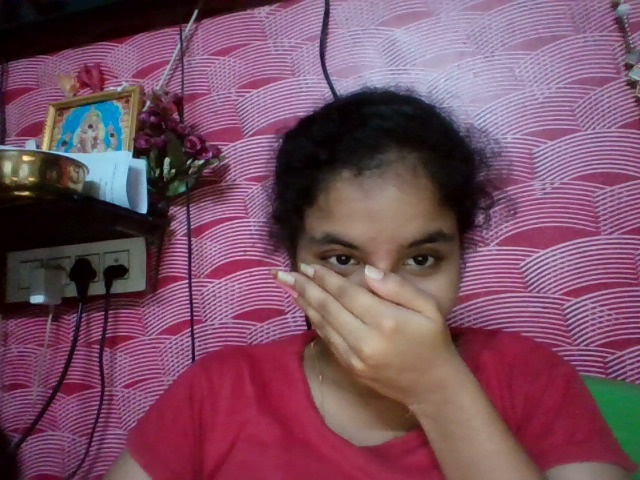

C:\Users\Surendra/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:931: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [ ]:
def run_real_time_object_detection():
    # Open the camera or video stream
    video_stream = cv2.VideoCapture(0)

    while True:
        ret, frame = video_stream.read()
        if not ret:
            break

        # Perform object detection on the current frame
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # YOLOv5 expects RGB images
        frame = detect_objects(frame, model, labels)
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)  # Convert back to BGR for OpenCV display

        # Display the result in real-time
        _, buffer = cv2.imencode('.jpg', frame)
        frame_image = buffer.tobytes()
        clear_output(wait=True)
        display(Image(data=frame_image))

        # Exit the loop when the 'q' key is pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Release the video stream and close the OpenCV windows
    video_stream.release()
    cv2.destroyAllWindows()

if __name__ == '__main__':
    run_real_time_object_detection()